In [1]:
!pip install pandas matplotlib


In [2]:
import sqlite3

# Create (or open) a SQLite database file called sales_data.db
conn = sqlite3.connect("sales_data.db")
cur = conn.cursor()

# Create a table called 'sales' if it doesn't exist already
cur.execute("""
CREATE TABLE IF NOT EXISTS sales (
    order_id INTEGER,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

# Save the table structure
conn.commit()
print("✅ Database and 'sales' table ready.")


✅ Database and 'sales' table ready.


In [3]:
# Insert sample rows (only once)
cur.execute("SELECT COUNT(*) FROM sales")
count = cur.fetchone()[0]

if count == 0:
    sample_data = [
        (1, 'T-shirt', 3, 15.00),
        (2, 'T-shirt', 2, 15.00),
        (3, 'Mug', 5, 8.50),
        (4, 'Cap', 1, 12.00),
        (5, 'Mug', 2, 8.50),
        (6, 'Poster', 4, 5.00),
        (7, 'T-shirt', 1, 15.00),
        (8, 'Cap', 3, 12.00),
        (9, 'Poster', 2, 5.00),
        (10, 'Mug', 1, 8.50)
    ]
    cur.executemany("INSERT INTO sales VALUES (?, ?, ?, ?)", sample_data)
    conn.commit()
    print("✅ Added sample sales data into the table.")
else:
    print("ℹ️ Data already exists in the table.")


✅ Added sample sales data into the table.


In [4]:
import pandas as pd

query = """
SELECT product,
       SUM(quantity) AS total_qty,
       SUM(quantity * price) AS total_revenue
FROM sales
GROUP BY product
"""

df = pd.read_sql_query(query, conn)
print("✅ Query executed successfully!\n")
print(df)


✅ Query executed successfully!

   product  total_qty  total_revenue
0      Cap          4           48.0
1      Mug          8           68.0
2   Poster          6           30.0
3  T-shirt          6           90.0


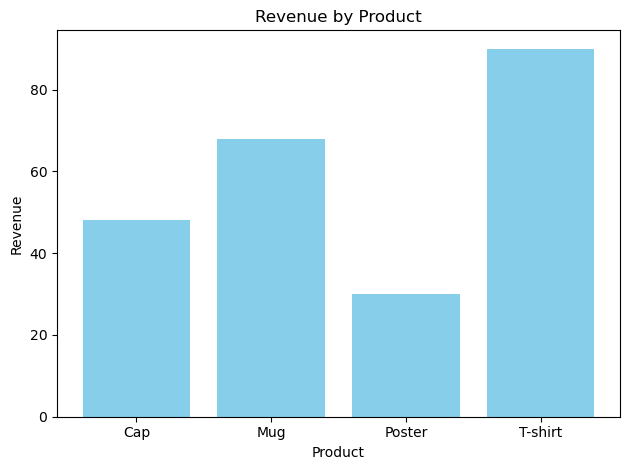

In [5]:
import matplotlib.pyplot as plt

plt.bar(df["product"], df["total_revenue"], color="skyblue")
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("sales_chart.png")  # Saves the chart as an image
plt.show()
